# World Bank Nicaragua Economy 2000-2024

### 🎯 Main Objective

##### Analize Nicaragua's macroeconomic evolution between 2000 and 2024, evaluating grow, economic stability and other elements using basic data analysis tools and SQL.

### 🎯 Specific Goals

##### 1. Clean and structure the original World Bank dataset into a standardized format.

##### 2. Design a relational database using SQLite for efficient data management.

##### 3. Analyze temporal trends across economic indicators.

##### 4. Identify periods of stability, crises, or structural shifts within the timeline.

##### 5. Evaluate descriptive relationships between GDP growth, inflation, unemployment, population, and remittances.

##### 6. Formulate economic conclusions driven by quantitative evidence.

### 📌 Selected Indicators

##### 📈 Growth
  1.	GDP per capita (current US$)
  2.	GDP growth (annual %)

##### 💰 Macroeconomic Stability
  3.	Inflation, consumer prices (annual %)
  4.	Unemployment, total (% of total labor force)

##### 🌍 Structural Context
  5.	Population, total
  6.	Personal remittances received (% of GDP)


## Introduction

##### The macroeconomic analysis lets understand the evaluation of a country over indicators that reflects the country's growth, stability and structural characteristics. In this project, Nicargua's economic behavior will be analyzed during the 2000-2024 period.

##### The data used is provided by the World Bank dataset that includes many economic indicators. From this dataset a selected group of indicators were chosen. These represent three fundamental dimensions of economy: growth (GDP per capita and anual growth), stability (inflation and unemployement) and structural elements (total population and remittances).

##### This analysis objective is to identify trends, possible periods of volatility and descriptive relationships between variables, using basic data analysis tools and SQL.

## Dataset Exploration

#### Libraries

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

#### Dataset Loading

In [6]:
df2 = pd.read_csv('wd_nicaragua.csv')
df2.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,Unnamed: 69
0,Nicaragua,NIC,Refugees under the mandate of the UNRWA by cou...,SM.POP.RRWA.EA,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Nicaragua,NIC,Other people in need of international protecti...,SM.POP.OPIP.EA,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,NaN,NaN
2,Nicaragua,NIC,Asylum-seekers by country or territory of origin,SM.POP.ASYS.EO,NaN,NaN,NaN,NaN,NaN,NaN,...,2125.0,2722.0,32265.0,66869.0,62085.0,164019.0,277663.0,308032.0,356201.0,NaN
3,Nicaragua,NIC,"Children in employment, wage workers, female (...",SL.WAG.0714.FE.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Nicaragua,NIC,"Unemployment, male (% of male labor force) (na...",SL.UEM.TOTL.MA.NE.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,3.6,3.1,5.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
# Dataset Dimensions
print('Dataset Dimensions:', df2.shape)

print('\nDataset Total Indicators: ', len(df2['Indicator Name']))

print('\nTotal number of years: ', len(df2.loc[0, '1960':]))

print('\nNull Values: ', df2.isnull().sum().sum())

Dataset Dimensions: (1513, 70)

Dataset Total Indicators:  1513

Total number of years:  66

Null Values:  58216


In [8]:
df2[
    df2['Indicator Name'].str.contains('gdp', case=False) &
    df2['Indicator Name'].str.contains('annual', case=False)
]
df2[
    df2['Indicator Name'].str.contains('gdp', case=False) &
    df2['Indicator Name'].str.contains('capita', case=False)
]
df2[
    df2['Indicator Name'].str.contains('inflation', case=False)
]
df2[
    df2['Indicator Name'].str.contains('unemployment', case=False) &
    df2['Indicator Name'].str.contains('total', case=False)
]
df2[
    df2['Indicator Name'].str.contains('population', case=False) &
    df2['Indicator Name'].str.contains('total', case=False)
]
df2[
    df2['Indicator Name'].str.contains('remittances', case=False) &
    df2['Indicator Name'].str.contains('gdp', case=False)
]

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,Unnamed: 69
187,Nicaragua,NIC,"Personal remittances, received (% of GDP)",BX.TRF.PWKR.DT.GD.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,9.544566,10.116864,11.55297,13.279761,14.575974,15.130529,20.641434,26.184103,26.635547,NaN


In [9]:
indicators_codes = [
    'NY.GDP.PCAP.PP.CD',
    'NY.GDP.MKTP.KD.ZG',
    'FP.CPI.TOTL.ZG',
    'SL.UEM.TOTL.ZS',
    'SP.POP.TOTL',
    'BX.TRF.PWKR.DT.GD.ZS'
]

df = df2[df2['Indicator Code'].isin(indicators_codes)]

years = [str(year) for year in range(2000, 2024)]

df = df[['Indicator Name', 'Indicator Code'] + years]
df = df.reset_index(drop=True)
df

,Indicator Name,Indicator Code,2000,2001,2002,2003,2004,2005,2006,2007,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,"GDP per capita, PPP (current international $)",NY.GDP.PCAP.PP.CD,2.806259e+03,2.916552e+03,2.948230e+03,3.046109e+03,3.255485e+03,3.455993e+03,3.657967e+03,3.891500e+03,...,5.067746e+03,5.448892e+03,5.882366e+03,6.225347e+03,5.935167e+03,5.981109e+03,6.274095e+03,7.119169e+03,7.796694e+03,8.319979e+03
1,"Personal remittances, received (% of GDP)",BX.TRF.PWKR.DT.GD.ZS,6.262737e+00,6.272712e+00,7.207497e+00,8.244667e+00,8.955740e+00,9.740048e+00,1.031245e+01,9.963123e+00,...,9.597289e+00,9.387227e+00,9.544566e+00,1.011686e+01,1.155297e+01,1.327976e+01,1.457597e+01,1.513053e+01,2.064143e+01,2.618410e+01
2,"Population, total",SP.POP.TOTL,5.022633e+06,5.087825e+06,5.149909e+06,5.210963e+06,5.272912e+06,5.342105e+06,5.418855e+06,5.497243e+06,...,6.066492e+06,6.149417e+06,6.232666e+06,6.316231e+06,6.400080e+06,6.483657e+06,6.565267e+06,6.644741e+06,6.730654e+06,6.823613e+06
3,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,4.101590e+00,2.960843e+00,7.539389e-01,2.520733e+00,5.312171e+00,4.282398e+00,4.152946e+00,5.076352e+00,...,4.785460e+00,4.792268e+00,4.563147e+00,4.631208e+00,-3.363357e+00,-2.896870e+00,-2.236542e+00,1.045439e+01,3.550299e+00,4.427744e+00
4,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,7.069914e+00,5.986042e+00,3.750175e+00,5.302388e+00,8.470211e+00,9.599100e+00,9.140200e+00,1.112693e+01,...,6.035969e+00,3.997380e+00,3.523173e+00,3.850672e+00,4.947237e+00,5.376290e+00,3.681813e+00,4.928414e+00,1.046742e+01,8.387659e+00
5,"Unemployment, total (% of total labor force) (...",SL.UEM.TOTL.ZS,7.181000e+00,7.222000e+00,7.517000e+00,7.600000e+00,6.410000e+00,5.370000e+00,5.310000e+00,4.890000e+00,...,4.520000e+00,4.700000e+00,3.900000e+00,3.300000e+00,5.200000e+00,5.457000e+00,6.180000e+00,6.076000e+00,4.969000e+00,4.698000e+00


#### Wide to Long Dataset

In [10]:
df = df.melt(
    id_vars=['Indicator Name', 'Indicator Code'],
    value_vars=years,
    var_name='Year',
    value_name='Value'
)
df.head(n=10)

,Indicator Name,Indicator Code,Year,Value
0,"GDP per capita, PPP (current international $)",NY.GDP.PCAP.PP.CD,2000,2.806259e+03
1,"Personal remittances, received (% of GDP)",BX.TRF.PWKR.DT.GD.ZS,2000,6.262737e+00
2,"Population, total",SP.POP.TOTL,2000,5.022633e+06
3,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,2000,4.101590e+00
4,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,2000,7.069914e+00
5,"Unemployment, total (% of total labor force) (...",SL.UEM.TOTL.ZS,2000,7.181000e+00
6,"GDP per capita, PPP (current international $)",NY.GDP.PCAP.PP.CD,2001,2.916552e+03
7,"Personal remittances, received (% of GDP)",BX.TRF.PWKR.DT.GD.ZS,2001,6.272712e+00
8,"Population, total",SP.POP.TOTL,2001,5.087825e+06
9,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,2001,2.960843e+00


In [11]:
# Cambiar columna Year a tipo int
df['Year'] = df['Year'].astype(int)
df.dtypes

Indicator Name     object
Indicator Code     object
Year                int64
Value             float64
dtype: object

In [12]:
print(f'There are {df.isnull().sum().sum()} nulls in the DataFrame')


There are 0 nulls in the DataFrame


In [13]:
category_map = {
    'NY.GDP.PCAP.PP.CD' : 'Growth',
    'BX.TRF.PWKR.DT.GD.ZS' : 'Structural',
    'SP.POP.TOTL' : 'Structural',
    'NY.GDP.MKTP.KD.ZG' : 'Growth',
    'FP.CPI.TOTL.ZG' : 'Stability',
    'SL.UEM.TOTL.ZS' : 'Stability'
}

df['Category'] = df['Indicator Code'].map(category_map)
df

,Indicator Name,Indicator Code,Year,Value,Category
0,"GDP per capita, PPP (current international $)",NY.GDP.PCAP.PP.CD,2000,2.806259e+03,Growth
1,"Personal remittances, received (% of GDP)",BX.TRF.PWKR.DT.GD.ZS,2000,6.262737e+00,Structural
2,"Population, total",SP.POP.TOTL,2000,5.022633e+06,Structural
3,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,2000,4.101590e+00,Growth
4,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,2000,7.069914e+00,Stability
...,...,...,...,...,...
139,"Personal remittances, received (% of GDP)",BX.TRF.PWKR.DT.GD.ZS,2023,2.618410e+01,Structural
140,"Population, total",SP.POP.TOTL,2023,6.823613e+06,Structural
141,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,2023,4.427744e+00,Growth
142,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,2023,8.387659e+00,Stability


## Database Building

#### Config Prettytable

In [14]:
import prettytable

prettytable.DEFAULT = 'DEFAULT'

#### Creating the Database and loading sql magic

In [15]:
conn = sqlite3.connect('WDnic.DB')
cur = conn.cursor()

In [16]:
%load_ext sql

#### Converting the DataFrame to an SQL Table in the Database

In [17]:
df.to_sql('wd_nic_data', conn, if_exists='replace', index=False)

144

In [18]:
%sql sqlite:///WDnic.db

#### Verifying the Table Integrity

In [19]:
%sql SELECT name, type, length(type) FROM PRAGMA_TABLE_INFO('wd_nic_data')

 * sqlite:///WDnic.db
Done.


name,type,length(type)
Indicator Name,TEXT,4
Indicator Code,TEXT,4
Year,INTEGER,7
Value,REAL,4
Category,TEXT,4


## Descriptive Analysis (SQL)

### Ends and Trends

#### Most Inflation Year

In [22]:
%sql SELECT "Indicator Name", Year, ROUND(Value, 3) AS Value \
    FROM wd_nic_data WHERE "Indicator Code" = 'FP.CPI.TOTL.ZG' \
    ORDER BY Value DESC LIMIT 1;

 * sqlite:///WDnic.db
Done.


Indicator Name,Year,Value
"Inflation, consumer prices (annual %)",2008,19.826


#### Year with the Highest GDP Growth

In [23]:
%sql SELECT "Indicator Name", Year, ROUND(Value, 3) AS Value \
    FROM wd_nic_data WHERE "Indicator Code" = 'NY.GDP.MKTP.KD.ZG' \
    ORDER BY Value DESC LIMIT 1;

 * sqlite:///WDnic.db
Done.


Indicator Name,Year,Value
GDP growth (annual %),2021,10.454


#### Lowest GDP Growth

In [24]:
%sql SELECT "Indicator Name", Year, ROUND(Value, 3) AS Value \
    FROM wd_nic_data WHERE "Indicator Code" = 'NY.GDP.MKTP.KD.ZG' \
    ORDER BY Value LIMIT 1;

 * sqlite:///WDnic.db
Done.


Indicator Name,Year,Value
GDP growth (annual %),2018,-3.363


#### Highest Unemployement Rate Year

In [25]:
%sql SELECT "Indicator Name", Year, ROUND(Value, 3) AS Value \
    FROM wd_nic_data WHERE "Indicator Code" = 'SL.UEM.TOTL.ZS' \
    ORDER BY Value DESC LIMIT 1;

 * sqlite:///WDnic.db
Done.


Indicator Name,Year,Value
"Unemployment, total (% of total labor force) (modeled ILO estimate)",2009,8.16


#### Highest Remittances Rate

In [26]:
%sql SELECT "Indicator Name", Year, ROUND(Value, 3) AS Value \
    FROM wd_nic_data WHERE "Indicator Code" = 'BX.TRF.PWKR.DT.GD.ZS' \
    ORDER BY Value DESC LIMIT 1;

 * sqlite:///WDnic.db
Done.


Indicator Name,Year,Value
"Personal remittances, received (% of GDP)",2023,26.184


### Time Comparisons

#### Average Inflation: 2000-2010 vs 2011-2024

In [35]:
%%sql 
SELECT "Indicator Name",
    CASE
        WHEN Year BETWEEN 2000 AND 2010 THEN '2000-2010'
        ELSE '2011-2024'
    END AS Period,
ROUND(AVG(Value),3) AS Value
FROM wd_nic_data WHERE "Indicator Code" = 'FP.CPI.TOTL.ZG' GROUP BY "Indicator Name", Period;

 * sqlite:///WDnic.db
Done.


Indicator Name,Period,Value
"Inflation, consumer prices (annual %)",2000-2010,8.128
"Inflation, consumer prices (annual %)",2011-2024,5.97


#### Average GDP Growth 2000-2010 vs 2011-2024

In [36]:
%%sql 
SELECT "Indicator Name",
    CASE
        WHEN Year BETWEEN 2000 AND 2010 THEN '2000-2010'
        ELSE '2011-2024'
    END AS Period,
ROUND(AVG(Value),3) AS Value
FROM wd_nic_data WHERE "Indicator Code" = 'NY.GDP.MKTP.KD.ZG' GROUP BY "Indicator Name", Period;

 * sqlite:///WDnic.db
Done.


Indicator Name,Period,Value
GDP growth (annual %),2000-2010,3.065
GDP growth (annual %),2011-2024,3.573


#### Average GDP Per Capita Growth 2005-2024

In [40]:
%%sql
SELECT "Indicator Name", ROUND(AVG(Value), 3) AS Value
FROM wd_nic_data
WHERE "Indicator Code" = 'NY.GDP.PCAP.PP.CD';

 * sqlite:///WDnic.db
Done.


Indicator Name,Value
"GDP per capita, PPP (current international $)",4814.09


## Data Visualization

## Single Indicators Graphs

### GDP Per Capita

Text(0, 0.5, 'GDP Per Capita (USD)')

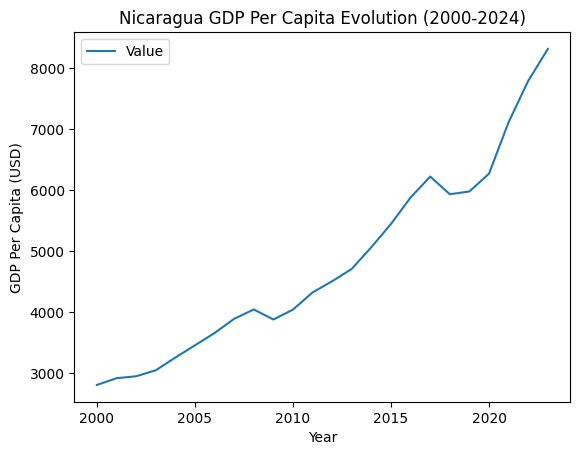

In [50]:
# Esta seccion devuelve las filas con esa condicion en especifico [df["Indicator Code"] == 'NY.GDP.PCAP.PP.CD']
# Esta seccion elige las columnas del df sobre el resultado filtrado [['Year', 'Value']]
df_gdp_per_capita = df[df["Indicator Code"] == 'NY.GDP.PCAP.PP.CD'][['Year', 'Value']]
df_gdp_per_capita.sort_values(by='Year')

ax = df_gdp_per_capita.plot(x='Year', y='Value')
ax.set_title('Nicaragua GDP Per Capita Evolution (2000-2024)')
ax.set_xlabel('Year')
ax.set_ylabel('GDP Per Capita (USD)')

### GDP Annual Growth

Text(0, 0.5, 'GDP Growth Rate (%)')

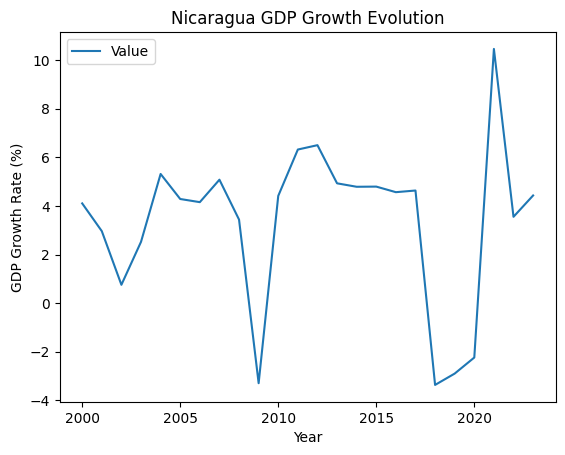

In [51]:
df_gdp_growth = df[df["Indicator Code"] == 'NY.GDP.MKTP.KD.ZG'][['Year', 'Value']]
df_gdp_growth.sort_values(by='Year')

ax = df_gdp_growth.plot(x='Year', y='Value')
ax.set_title('Nicaragua GDP Growth Evolution')
ax.set_xlabel('Year')
ax.set_ylabel('GDP Growth Rate (%)')

### Inflation Rate

Text(0, 0.5, 'Inflation Rate (%)')

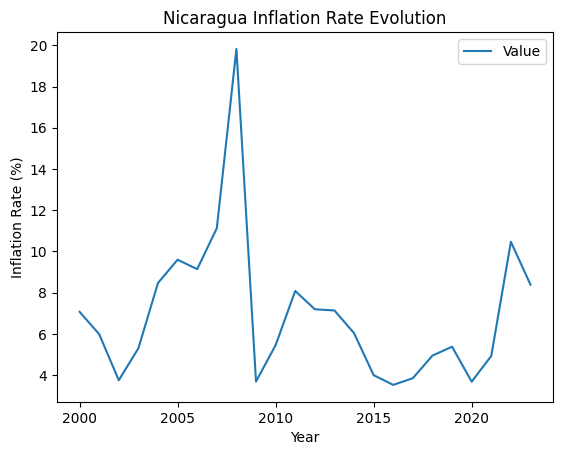

In [52]:
df_inflation = df[df["Indicator Code"] == 'FP.CPI.TOTL.ZG'][['Year', 'Value']]
df_inflation.sort_values(by='Year')

ax = df_inflation.plot(x='Year', y='Value')
ax.set_title('Nicaragua Inflation Rate Evolution')
ax.set_xlabel('Year')
ax.set_ylabel('Inflation Rate (%)')

### Unemployement Rate

Text(0, 0.5, 'Unemployement Rate (%)')

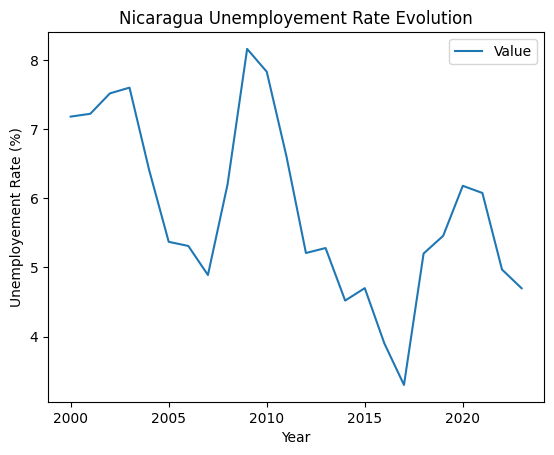

In [53]:
df_unemployement = df[df["Indicator Code"] == 'SL.UEM.TOTL.ZS'][['Year', 'Value']]
df_unemployement.sort_values(by='Year')

ax = df_unemployement.plot(x='Year', y='Value')
ax.set_title('Nicaragua Unemployement Rate Evolution')
ax.set_xlabel('Year')
ax.set_ylabel('Unemployement Rate (%)')

### Remmitances

Text(0, 0.5, 'Remmitances (% of GDP)')

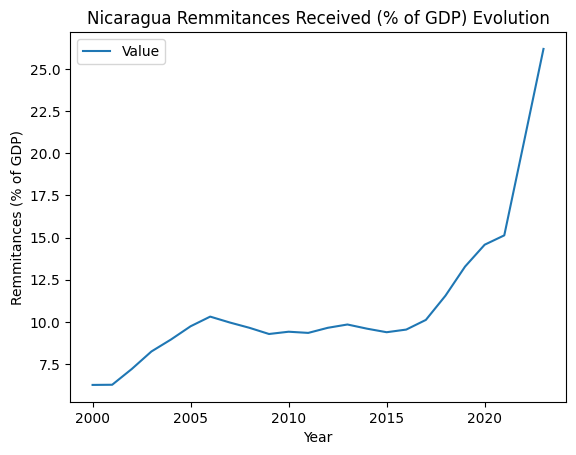

In [54]:
df_remmitances = df[df["Indicator Code"] == 'BX.TRF.PWKR.DT.GD.ZS'][['Year', 'Value']]
df_remmitances.sort_values(by='Year')

ax = df_remmitances.plot(x='Year', y='Value')
ax.set_title('Nicaragua Remmitances Received (% of GDP) Evolution')
ax.set_xlabel('Year')
ax.set_ylabel('Remmitances (% of GDP)')

### Total Population

Text(0, 0.5, 'Total Population (Millions)')

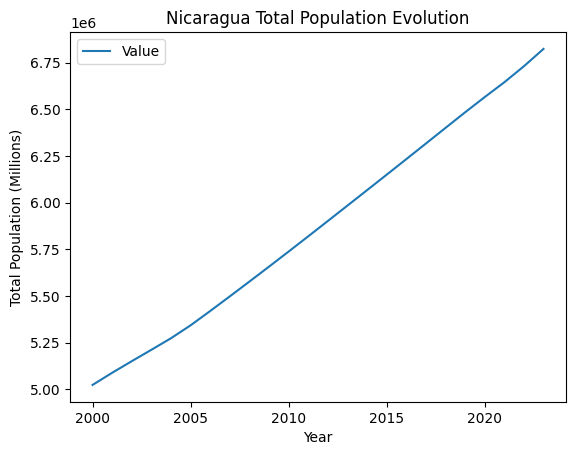

In [56]:
df_population = df[df["Indicator Code"] == 'SP.POP.TOTL'][['Year', 'Value']]
df_population.sort_values(by='Year')

ax = df_population.plot(x='Year', y='Value')
ax.set_title('Nicaragua Total Population Evolution')
ax.set_xlabel('Year')
ax.set_ylabel('Total Population (Millions)')

## Indicator Comparisons

### GDP Growth vs Inflation Rate

Text(0, 0.5, 'Rate (%)')

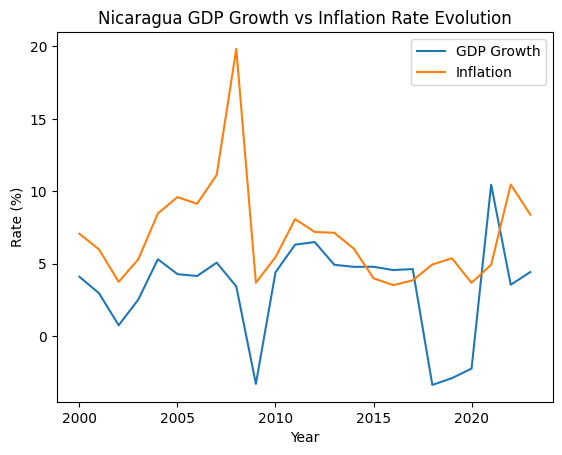

In [64]:
ax = df_gdp_growth.plot(x='Year', y='Value', label='GDP Growth')
df_inflation.plot(x='Year', y='Value', ax=ax, label='Inflation')

ax.set_title('Nicaragua GDP Growth vs Inflation Rate Evolution')
ax.set_ylabel('Rate (%)')

### GDP Growth vs Unemployement Rate

Text(0, 0.5, 'Rate (%)')

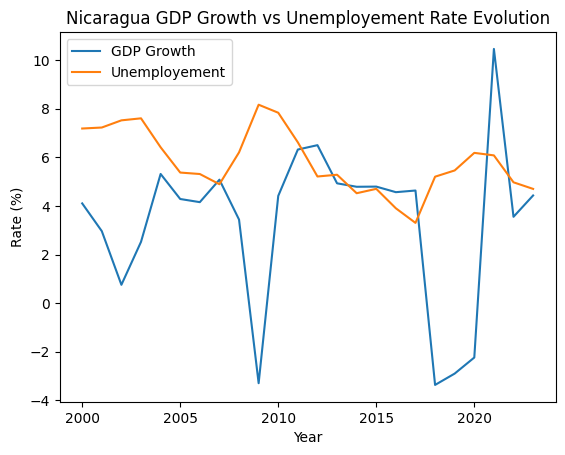

In [65]:
ax = df_gdp_growth.plot(x='Year', y='Value', label='GDP Growth')
df_unemployement.plot(x='Year', y='Value', ax=ax, label='Unemployement')

ax.set_title('Nicaragua GDP Growth vs Unemployement Rate Evolution')
ax.set_ylabel('Rate (%)')